# 08 — Ensemble & Stacking (Final Stage)
We have trained FIVE models from different families:
1. **LightGBM** (Boosting - Leaf-wise)
2. **XGBoost** (Boosting - Level-wise)
3. **Random Forest** (Bagging)
4. **Neural Network** (Deep Learning)
5. **CatBoost** (Boosting - Symmetric Trees)

In this notebook, we combine them using two methods:
- **Simple Averaging**: Quick and often very effective.
- **Stacking**: Training a "Meta-Model" (Logistic Regression) on the OOF predictions to learn the optimal weights.

In [1]:
# Mount Google Drive - run this first on Colab
from google.colab import drive
drive.mount('/content/drive')

# Set your project path on Drive
DRIVE_PATH = '/content/drive/MyDrive/santander-customer-satisfaction/'
PICKLE_DIR = DRIVE_PATH + 'pickles/'
SUBMIT_DIR = DRIVE_PATH + 'submissions/'

import os
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print('Setup complete.')

Mounted at /content/drive
Setup complete.


## 1. Load All Out-Of-Fold (OOF) and Test Predictions

In [2]:
# Load OOF Predictions (for training meta-model)
lgbm_oof = pd.read_pickle(f'{PICKLE_DIR}lgbm_oof.pkl')
xgb_oof = pd.read_pickle(f'{PICKLE_DIR}xgb_oof.pkl')
rf_oof = pd.read_pickle(f'{PICKLE_DIR}rf_oof.pkl')
nn_oof = pd.read_pickle(f'{PICKLE_DIR}nn_oof.pkl')
cat_oof = pd.read_pickle(f'{PICKLE_DIR}catboost_oof.pkl')

# Load Test Predictions (for final submission)
lgbm_test = pd.read_pickle(f'{PICKLE_DIR}lgbm_test_preds.pkl')
xgb_test = pd.read_pickle(f'{PICKLE_DIR}xgb_test_preds.pkl')
rf_test = pd.read_pickle(f'{PICKLE_DIR}rf_test_preds.pkl')
nn_test = pd.read_pickle(f'{PICKLE_DIR}nn_test_preds.pkl')
cat_test = pd.read_pickle(f'{PICKLE_DIR}catboost_test_preds.pkl')

# Load Target (Truth)
train_clean = pd.read_pickle(f'{PICKLE_DIR}train_clean.pkl')
y_true = train_clean['TARGET']

# Create OOF DataFrame
oof_df = pd.DataFrame({
    'lgbm': lgbm_oof['lgbm_pred'],
    'xgb': xgb_oof['xgb_pred'],
    'rf': rf_oof['rf_pred'],
    'nn': nn_oof['nn_pred'],
    'cat': cat_oof['cat_pred']
})

# Create Test DataFrame
test_df = pd.DataFrame({
    'lgbm': lgbm_test['lgbm_pred'],
    'xgb': xgb_test['xgb_pred'],
    'rf': rf_test['rf_pred'],
    'nn': nn_test['nn_pred'],
    'cat': cat_test['cat_pred']
})

print("Loaded all predictions.")
oof_df.head()

Loaded all predictions.


,lgbm,xgb,rf,nn,cat
0,0.032553,0.036010,0.031377,0.029969,0.036398
1,0.029104,0.014562,0.031022,0.007125,0.023026
2,0.003841,0.003050,0.002351,0.000764,0.005539
3,0.030165,0.020774,0.029696,0.023644,0.040405
4,0.018070,0.014695,0.013803,0.010796,0.015443


## 2. Model Correlation Check
Diversity is key! If models are too highly correlated (e.g. > 0.98), ensembling them won't help much.

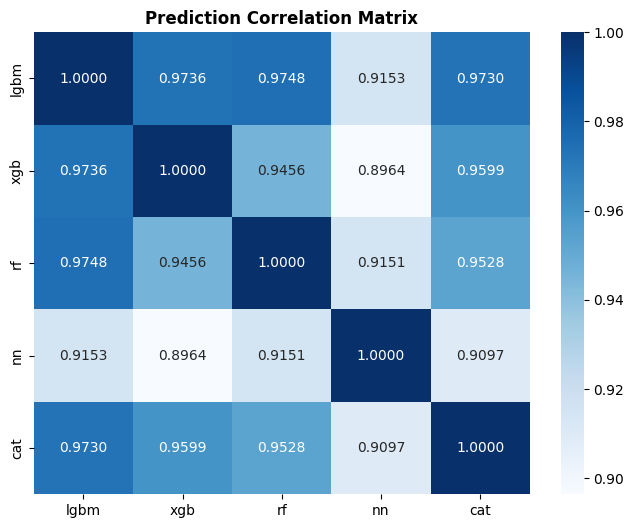

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(oof_df.corr(), annot=True, cmap='Blues', fmt='.4f')
plt.title('Prediction Correlation Matrix', fontweight='bold')
plt.show()

## 3. Simple Averaging
Let's see the AUC if we just take a straight average.

In [4]:
avg_oof = oof_df.mean(axis=1)
avg_auc = roc_auc_score(y_true, avg_oof)

print(f"Simple Average OOF AUC: {avg_auc:.5f}")

# Individual Scores for comparison
for col in oof_df.columns:
    score = roc_auc_score(y_true, oof_df[col])
    print(f"Individual {col} AUC: {score:.5f}")

Simple Average OOF AUC: 0.84132
Individual lgbm AUC: 0.84101
Individual xgb AUC: 0.83469
Individual rf AUC: 0.83851
Individual nn AUC: 0.82589
Individual cat AUC: 0.83853


## 4. Stacking (Meta-Modeling)
We use **Logistic Regression** as the meta-model to learn which models to trust more.

In [5]:
meta_model = LogisticRegression(solver='liblinear', random_state=42)
meta_model.fit(oof_df, y_true)

# Weights assigned by the meta-model
weights = pd.DataFrame({
    'Model': oof_df.columns,
    'Weight': meta_model.coef_[0]
}).sort_values(by='Weight', ascending=False)

print("Meta-Model Weights:")
print(weights)

# Predict using Meta-Model
stacked_oof = meta_model.predict_proba(oof_df)[:, 1]
stacked_auc = roc_auc_score(y_true, stacked_oof)

print(f"\nStacked Meta-Model OOF AUC: {stacked_auc:.5f}")

Meta-Model Weights:
  Model    Weight
2    rf  8.396543
0  lgbm  3.529732
3    nn  1.541000
4   cat  0.913710
1   xgb  0.187292

Stacked Meta-Model OOF AUC: 0.84102


## 5. Generate Final Submissions

In [6]:
# 1. Simple Average Submission
avg_test_preds = test_df.mean(axis=1)
avg_sub = pd.DataFrame({'ID': lgbm_test['ID'], 'TARGET': avg_test_preds})
avg_sub.to_csv(f'{SUBMIT_DIR}ensemble_average_submission_v2.csv', index=False)

# 2. Stacked Meta-Model Submission
stacked_test_preds = meta_model.predict_proba(test_df)[:, 1]
stacked_sub = pd.DataFrame({'ID': lgbm_test['ID'], 'TARGET': stacked_test_preds})
stacked_sub.to_csv(f'{SUBMIT_DIR}ensemble_stacked_submission_v2.csv', index=False)

print("✅ Final Ensemble Submissions (with CatBoost) saved to Drive!")

✅ Final Ensemble Submissions (with CatBoost) saved to Drive!
